<a href="https://colab.research.google.com/github/xtianu/Docencia/blob/main/UT/Test/Tirana_CV_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Computer Vision - Tirana May 2026
# Final Evaluation Exercise: Complete the following exercises

Remember to send your solution to my email: christian.mata@upc.edu


## 1. Load and visualize the 'coins' image from the skimage built-in datasets. Report the size of the image and range of the pixel grayscale levels.

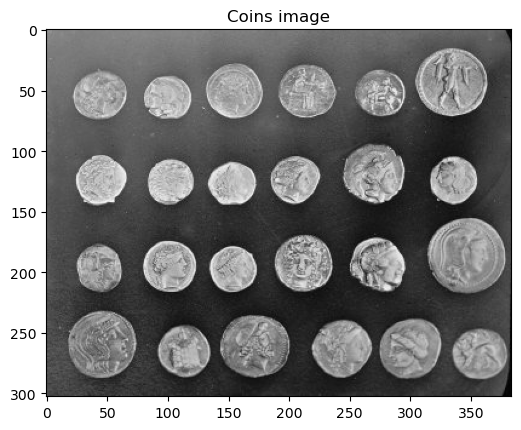

Image size: (303, 384)
Minimum grayscale level: 1
Maximum grayscale level: 252
Pixel value range: 1 - 252


In [45]:
import skimage as sk
import matplotlib.pyplot as plt

I = sk.data.coins()

plt.figure(figsize=(6, 5))
plt.imshow(I, cmap="gray")
plt.title("Coins image")
plt.show()

print("Image size:", I.shape)
print("Minimum grayscale level:", I.min())
print("Maximum grayscale level:", I.max())
print("Pixel value range:", I.min(), "-", I.max())

## 2. Represent the histogram of the image. Explain the peaks of the histogram in terms of regions of the image.

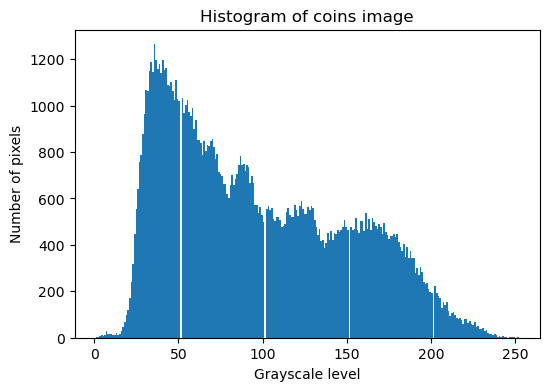

In [46]:
plt.figure(figsize=(6, 4))
plt.hist(I.ravel(), bins=256)
plt.title("Histogram of coins image")
plt.xlabel("Grayscale level")
plt.ylabel("Number of pixels")
plt.show()

**Explanation**: The histogram shows how many pixels exist for each grayscale value. 
For the `coins` image:

- Dark grayscale levels correspond mostly to the dark background/shadows.
- Medium grayscale levels correspond to the coin surfaces and texture.
- High grayscale levels correspond to bright parts of the coins and highlights.

So the peaks appear because the image contains large regions with similar intensities: background pixels, coin pixels, and bright reflections/details.

## 3. Applied noise to the image and use the correct function to erase the noise.

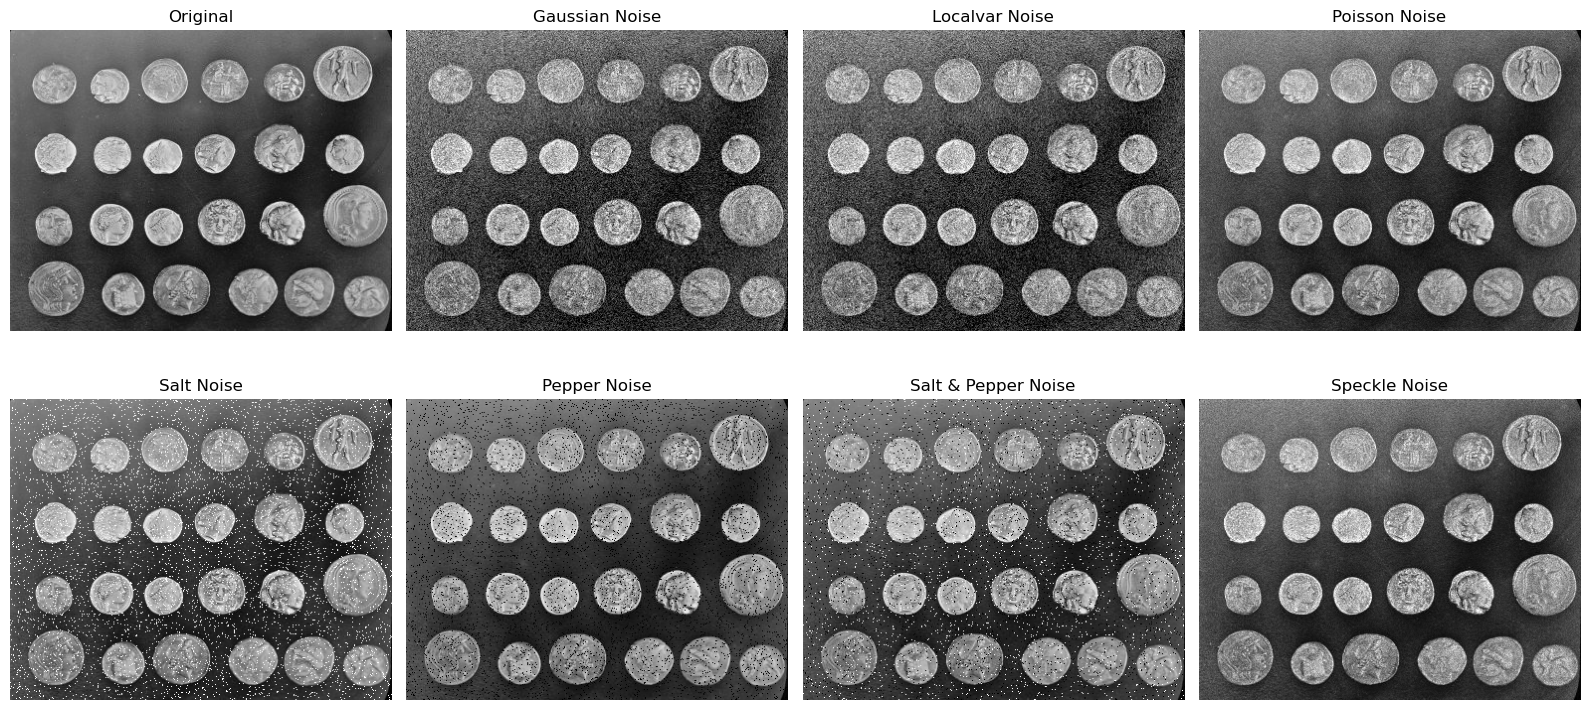

In [47]:
import matplotlib.pyplot as plt
import skimage as sk

# Generate noisy versions of the same image using different noise types
I_gaussian = sk.util.random_noise(I, mode="gaussian")
I_localvar = sk.util.random_noise(I,mode="localvar")
I_poisson = sk.util.random_noise(I, mode="poisson")
I_salt = sk.util.random_noise(I, mode="salt")
I_pepper = sk.util.random_noise(I, mode="pepper")
I_sp = sk.util.random_noise(I, mode="s&p")
I_speckle = sk.util.random_noise(I, mode="speckle")

images = [
    I,
    I_gaussian,
    I_localvar,
    I_poisson,
    I_salt,
    I_pepper,
    I_sp,
    I_speckle
]

titles = [
    "Original",
    "Gaussian Noise",
    "Localvar Noise",
    "Poisson Noise",
    "Salt Noise",
    "Pepper Noise",
    "Salt & Pepper Noise",
    "Speckle Noise"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for ax, im, title in zip(axes, images, titles):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

I have applied different type of noises seen during the lectures (based on the documentation of skimage).

**Noise Removal:** I have applied noise removal for the following noises:
- Gaussian: Using Gaussian filter.
- Salt&Pepper: Using Median Filter.

Gaussian noise affects many pixels slightly, so a Gaussian filter is used to smooth the image. 
Salt-and-pepper noise creates isolated black and white pixels, so a median filter is better because it removes these isolated noisy pixels while preserving edges better than simple smoothing.

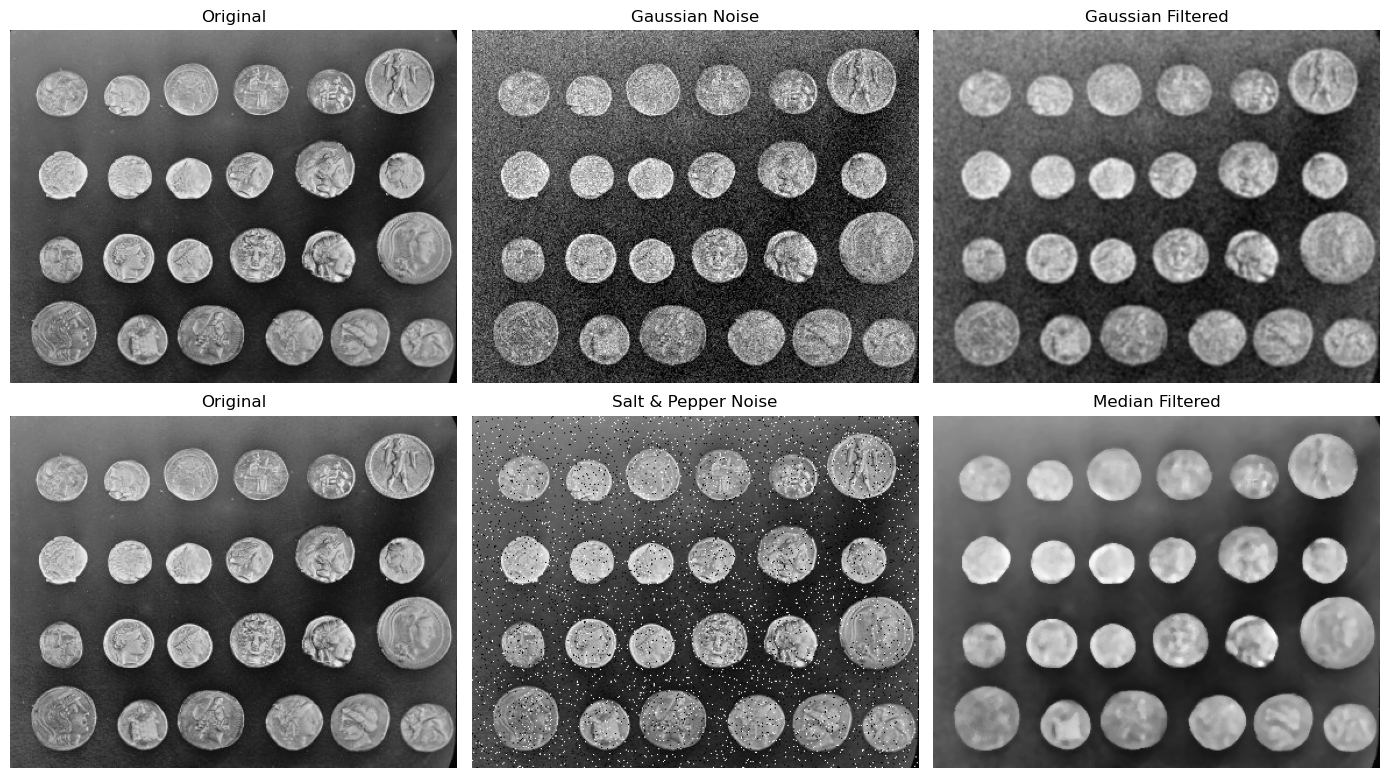

In [48]:
from skimage.filters import median, gaussian
from skimage.morphology import disk

# Remove Gaussian noise using Gaussian filter
I_gaussian_filtered = gaussian(I_gaussian, sigma=1)

# Remove Salt & Pepper noise using Median filter
I_sp_filtered = median(I_sp, footprint=disk(3))

fig, ax = plt.subplots(2, 3, figsize=(14, 8))

ax[0, 0].imshow(I, cmap="gray")
ax[0, 0].set_title("Original")
ax[0, 0].axis("off")

ax[0, 1].imshow(I_gaussian, cmap="gray")
ax[0, 1].set_title("Gaussian Noise")
ax[0, 1].axis("off")

ax[0, 2].imshow(I_gaussian_filtered, cmap="gray")
ax[0, 2].set_title("Gaussian Filtered")
ax[0, 2].axis("off")

ax[1, 0].imshow(I, cmap="gray")
ax[1, 0].set_title("Original")
ax[1, 0].axis("off")

ax[1, 1].imshow(I_sp, cmap="gray")
ax[1, 1].set_title("Salt & Pepper Noise")
ax[1, 1].axis("off")

ax[1, 2].imshow(I_sp_filtered, cmap="gray")
ax[1, 2].set_title("Median Filtered")
ax[1, 2].axis("off")

plt.tight_layout()
plt.show()

## 4. Segment the image using a k-means clustering algorithm with k=2 and represent the result

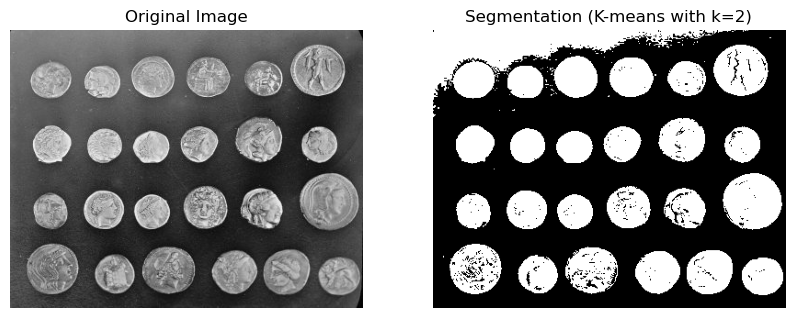

In [49]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.cluster import KMeans
import numpy as np

# reshape image into a vector of pixels
v_I = np.reshape(I, (I.shape[0] * I.shape[1], 1))

# K-means segmentation with k = 2
n_clus = 2
kmeans = KMeans(n_clusters=n_clus, random_state=0).fit(v_I)

v_kmeans = kmeans.predict(v_I)

# reshape result back to image size
I_kmeans = np.reshape(v_kmeans, (I.shape[0], I.shape[1]))

fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(1, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(I, cmap=plt.cm.gray)
ax1.set_title("Original Image")
ax1.set_axis_off()

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(I_kmeans, cmap=plt.cm.gray)
ax2.set_title("Segmentation (K-means with k={})".format(n_clus))
ax2.set_axis_off()

plt.show()

**Explanation**: The image is first reshaped into a list of pixel values, where each pixel is treated as one data point.

Then, *KMeans* with: `n_clusters = 2` separates the pixels into two groups based on their grayscale intensity. 
One cluster usually corresponds to the darker background, and the other cluster corresponds to brighter coin regions.

After prediction, the cluster labels are reshaped back to the original image size, producing a binary-like segmented image where the two classes are shown as different grayscale values.



## 5. Label the objects found in the image. Generate a figure with the original image and the labeled image. How many coins are there in the image?

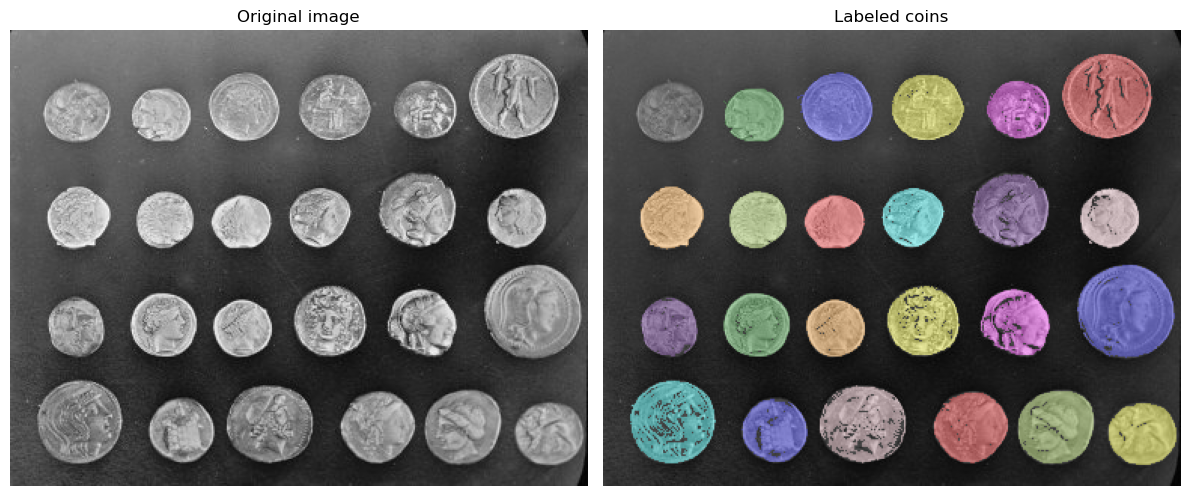

Number of coins: 23


In [50]:
from skimage.measure import label, regionprops
from skimage.color import label2rgb
import numpy as np
import matplotlib.pyplot as plt

# We use the segmented image from K-means
I_binary = I_kmeans

# Label connected regions
label_image = label(I_binary)

# We need to get regional properties for number of coins
props = regionprops(label_image)

coin_mask = np.zeros(label_image.shape, dtype=bool)

for region in props:
    # Keep only regions that are large enough and approximately circular
    if region.area > 100 and region.eccentricity < 0.9:
        coin_mask[label_image == region.label] = True

# Relabel only the coins
coin_labels = label(coin_mask)

# Count coins
props_coins = regionprops(coin_labels)
no_coins = len(props_coins)

# Create colored labeled image
labeled_overlay = label2rgb(coin_labels, image=I, bg_label=0)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(I, cmap="gray")
ax[0].set_title("Original image")
ax[0].axis("off")

ax[1].imshow(labeled_overlay)
ax[1].set_title("Labeled coins")
ax[1].axis("off")

plt.tight_layout()
plt.show()

print("Number of coins:", no_coins)

**Explanation:** Labeling means assigning a unique number to each connected object in the binary segmented image.

After K-means, the image has two classes: foreground and background. Then `label()` checks which foreground pixels are connected to each other and gives each connected region its own label.

So, if there are several separate coins, each coin receives a different label:

`label_image = label(I_binary)`

Then I used `regionprops(label_image)` to extract properties from each labelled object, such as area and eccentricity.

At first, I got an incorrect result because one coin was merged with a background region, so it was counted as a larger object. To fix this, I filtered the labelled regions by keeping only objects with enough area and an approximately circular shape:

`region.area > 100 and region.eccentricity < 0.8`

Finally, I relabelled the remaining regions and counted the number of coins as the number of filtered labelled regions.

## 6. Extract the area, major axis length and orientation of each coin. Report the average values of the extracted features. Represent a scatterplot of the area vs major axis length.  

In [35]:
import pandas as pd

#We can use prop_coins calculated in the previous step.

data = []

for region in props_coins:
    data.append({
        "label": region.label,
        "area": region.area,
        "major_axis_length": region.major_axis_length,
        "orientation": region.orientation
    })

df_coins = pd.DataFrame(data)

df_coins.head()

,label,area,major_axis_length,orientation
0,1,2459.0,59.966495,1.552547
1,2,1687.0,47.569623,1.330279
2,3,1631.0,47.608317,1.560757
3,4,1194.0,41.353879,1.376770
4,5,1135.0,40.092938,1.434892


In [36]:
average_features = df_coins[["area", "major_axis_length", "orientation"]].mean()

print("Average area:", average_features["area"])
print("Average major axis length:", average_features["major_axis_length"])
print("Average orientation:", average_features["orientation"])

Average area: 1569.6521739130435
Average major axis length: 46.802821601469105
Average orientation: 0.13728051272299693


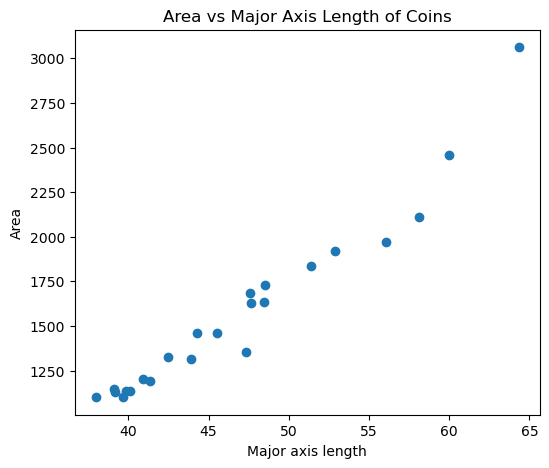

In [37]:
#Scatterplot of area vs. major axis length
plt.figure(figsize=(6, 5))
plt.scatter(df_coins["major_axis_length"], df_coins["area"])

plt.xlabel("Major axis length")
plt.ylabel("Area")
plt.title("Area vs Major Axis Length of Coins")

plt.show()

**Explanation**: Each labelled coin is treated as one region. `regionprops()` extracts geometric properties from every coin, then the values are stored in a pandas dataframe.  
The scatterplot shows the relation between the size of a coin and its major axis length.

There is a positive relationship between major_axis_length and area.

As the major axis length increases, the area also increases. This makes sense because larger coins have a longer main axis and occupy more pixels in the image.

The points are not perfectly on a straight line because the coins are not segmented perfectly and their shapes are not identical, but the general trend is clearly increasing.

## 7. Using the labeled regions from the 'coins' image, how can I filter the regions to find those with an area greater than 1750 pixels, count how many such coins there are?

In [38]:
# We can identify coins with area greater than 1750 pixels using a filter on the DataFrame
large_coins = df_coins[df_coins["area"] > 1750]

number_large_coins = len(large_coins)

print("There are ", number_large_coins, "coins with area greater than 1750 pixels.")

large_coin_labels = list(large_coins["label"])

print("Labels of coins with area greater than 1750 pixels:")
print(large_coin_labels)

There are  6 coins with area greater than 1750 pixels.
Labels of coins with area greater than 1750 pixels:
[1, 6, 12, 18, 19, 20]


##8. Generate a 3-panel figure with the original image, the image with the little coins < 1750 coins (red color) and an image with the big coins > 1750 (blue color).

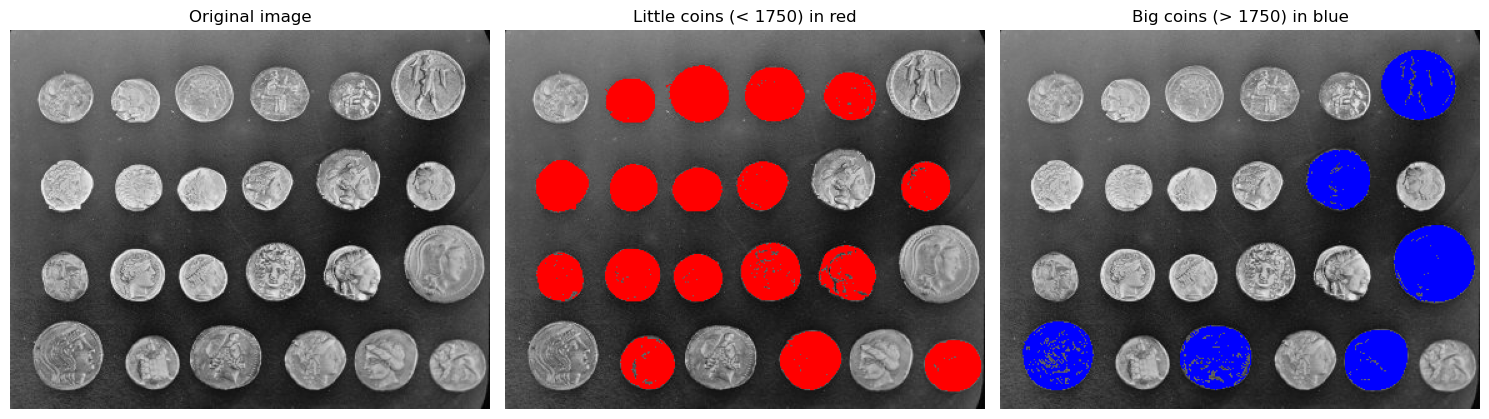

In [39]:
#We already found large coins above, now we find small coins.
small_coins = df_coins[df_coins["area"] < 1750]
small_coin_labels = list(small_coins["label"])

# We need to create binary masks
small_coin_mask = np.zeros(coin_labels.shape, dtype=bool)
large_coin_mask = np.zeros(coin_labels.shape, dtype=bool)

for lab in small_coin_labels:
    small_coin_mask[coin_labels == lab] = True

for lab in large_coin_labels:
    large_coin_mask[coin_labels == lab] = True

#Now we can create RGB images for small and large coins
I_small = np.stack([I, I, I], axis=2)
I_large = np.stack([I, I, I], axis=2)

I_small[small_coin_mask] = [255, 0, 0] # Red for small coins
I_large[large_coin_mask] = [0, 0, 255] # Blue for large coins


fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(I, cmap="gray")
ax[0].set_title("Original image")
ax[0].axis("off")

ax[1].imshow(I_small)
ax[1].set_title("Little coins (< 1750) in red")
ax[1].axis("off")

ax[2].imshow(I_large)
ax[2].set_title("Big coins (> 1750) in blue")
ax[2].axis("off")

plt.tight_layout()
plt.show()

## 9. Describe the main steps required to perform  segmentation of an RGB image using an unsupervised clustering algorithm (use other algorithms different than K-Means and compare the results)

**Steps for RGB image segmentation using unsupervised clustering:**

1. Load the RGB image.
2. Reshape the image from `(height, width, 3)` into a 2D array where each row is one pixel and the columns are the RGB values.
3. Apply an unsupervised clustering algorithm (i.e. Gaussian Mixture Model).
4. Predict the cluster label of each pixel.
5. Reshape the predicted labels back to the original image size.
6. Display the original image and the segmented result.

Then (*optional*):

7. Compare the result with K-Means segmentation.

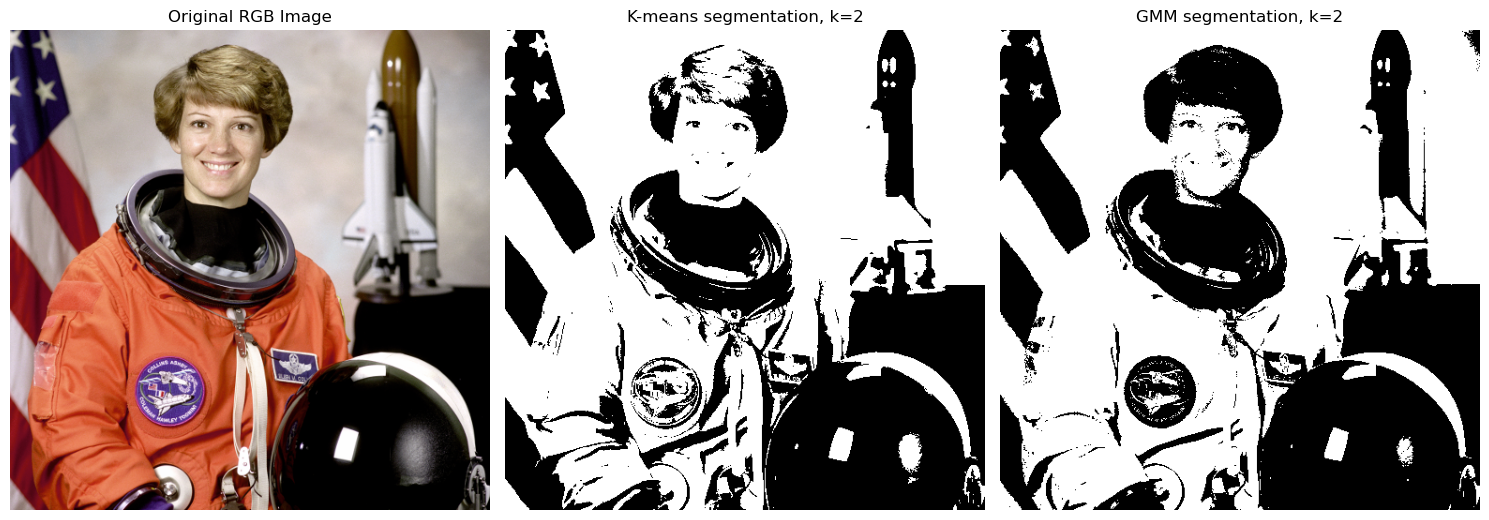

In [40]:
import skimage as sk
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.cluster import KMeans
from sklearn import mixture

# Load RGB image
I_rgb = sk.data.astronaut()

# Reshape RGB image into pixel feature vectors
v_I = np.reshape(I_rgb, (I_rgb.shape[0] * I_rgb.shape[1], I_rgb.shape[2]))

# Number of clusters
n_clus = 2

# K-means segmentation
kmeans = KMeans(n_clusters=n_clus, random_state=0).fit(v_I)
v_kmeans = kmeans.predict(v_I)
I_kmeans = np.reshape(v_kmeans, (I_rgb.shape[0], I_rgb.shape[1]))


# GMM segmentation
gmm = mixture.GaussianMixture(n_components=n_clus, random_state=0)
gmm.fit(v_I)
v_gmm = gmm.fit_predict(v_I)


I_gmm = np.reshape(v_gmm, (I_rgb.shape[0], I_rgb.shape[1]))

#Results
fig = plt.figure(figsize=(15, 6))
gs = gridspec.GridSpec(1, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(I_rgb)
ax1.set_title("Original RGB Image")
ax1.set_axis_off()

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(I_kmeans, cmap=plt.cm.gray)
ax2.set_title("K-means segmentation, k={}".format(n_clus))
ax2.set_axis_off()

ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(I_gmm, cmap=plt.cm.gray)
ax3.set_title("GMM segmentation, k={}".format(n_clus))
ax3.set_axis_off()

plt.tight_layout()
plt.show()

**Explanation:**  
For this exercise, I used the RGB `astronaut` image from the lecture exercises.

The previous segmentation was done on the grayscale `coins` image using K-means. However, for this exercise we need to describe segmentation of an **RGB image** using another unsupervised clustering algorithm. Therefore, I used the `astronaut` image because it is already RGB and each pixel contains three values: red, green, and blue.

I could not make a meaningful comparison by applying GMM to a different type of image than K-means, for example comparing grayscale coins with RGB astronaut. So, I applied both K-means and GMM to the same RGB image. This way, both methods use the same input data and the comparison is fair.

First, I reshaped the RGB image from `(height, width, 3)` into a 2D array where each row represents one pixel and the three columns represent the RGB values. Then I applied K-means and Gaussian Mixture Model separately with the same number of clusters, `k = 2`.

K-means separates pixels by assigning each pixel to the nearest cluster center. GMM also clusters pixels, but it models each cluster as a Gaussian distribution, so it can be more flexible because it considers the spread of the data.

Finally, I reshaped the predicted cluster labels back to the original image size and visualized the original RGB image, the K-means segmentation, and the GMM segmentation side by side.

## 10. Extract the main texture features of this image

In [43]:
from skimage.feature import graycomatrix, graycoprops
from skimage import img_as_ubyte
import pandas as pd

I_texture = img_as_ubyte(I)

texture_data = []

for region in props_coins:
    
    # mask for one labelled coin
    mask = coin_labels == region.label
    
    # bounding box of the coin
    minr, minc, maxr, maxc = region.bbox
    
    # crop image and mask around the coin
    region_image = I_texture[minr:maxr, minc:maxc]
    region_mask = mask[minr:maxr, minc:maxc]
    
    # keep only the coin pixels, background becomes 0
    region_image = region_image * region_mask
    
    # GLCM for this labelled region
    g = graycomatrix(
        region_image,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=False,
        normed=True
    )
    
    texture_data.append({
        "label": region.label,
        "Contrast": graycoprops(g, "contrast")[0, 0],
        "Dissimilarity": graycoprops(g, "dissimilarity")[0, 0],
        "Homogeneity": graycoprops(g, "homogeneity")[0, 0],
        "Energy": graycoprops(g, "energy")[0, 0],
        "Correlation": graycoprops(g, "correlation")[0, 0]
    })

df_texture_labels = pd.DataFrame(texture_data)

df_texture_labels.head()

,label,Contrast,Dissimilarity,Homogeneity,Energy,Correlation
0,1,2629.292676,27.513620,0.254959,0.210684,0.755599
1,2,1231.270186,16.098048,0.294657,0.236688,0.891888
2,3,1309.400792,19.231569,0.225079,0.176179,0.849305
3,4,2387.909499,27.727214,0.236488,0.199335,0.769214
4,5,1450.563370,18.643956,0.223810,0.153005,0.859704


## Personal discussion

I really enjoyed the Computer Vision course. It was fun to work with images and to learn that we can process and analyze them using basic mathematical and statistical operations. Before this course, I did not fully realize how many useful results can be obtained from simple operations such as thresholding, filtering, labeling, and extracting regional properties.

Through the exercises, I learned how images can be represented as arrays of pixels and how different techniques can be used to segment objects, remove noise, detect regions, and extract meaningful features such as area, eccentricity, orientation, and texture properties. I also appreciated working with real examples, because it made the theory easier to understand and apply.

The professor made the subject very interesting and enjoyable. The explanations were clear, and the atmosphere during the course was positive and motivating. I also liked that the professor was joyful and enthusiastic, because this made the lessons more engaging and helped me feel more interested in the topic.

Overall, I think this course gave me a good introduction to image processing and helped me understand how computer vision methods can be applied in practice. I hope we can meet again in the future, and thank you very much for making the course both useful and enjoyable.